# PROYECTO FINAL: Clasificación de Exoplanetas mediante Deep Learning
**Alumno:** Luis Marquina Rodríguez
**Asignatura:** Inteligencia Artificial

## Introducción
El objetivo de este proyecto es utilizar técnicas de **Deep Learning** (Aprendizaje Profundo) para procesar datos provenientes de la misión espacial Kepler de la NASA.
El dataset contiene observaciones de objetos de interés (KOI - Kepler Objects of Interest). Nuestro objetivo es entrenar una **Red Neuronal Artificial** capaz de clasificar estos objetos en tres categorías basándose en sus características físicas (radio, temperatura, órbita, etc.):
1. **CANDIDATE:** Posible planeta.
2. **CONFIRMED:** Planeta confirmado.
3. **FALSE POSITIVE:** Falsa alarma (estrella binaria, ruido, etc.).

In [ ]:
# PROYECTO FINAL IA: Clasificación de Exoplanetas (Kepler)
# Alumno: Luis Marquina Rodriguez
# Dataset: NASA Kepler Objects (arashnic)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Importamos las librerías de Deep Learning (Keras/TensorFlow)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow import keras
from tensorflow.keras import layers

# Configuración visual
plt.style.use('dark_background')
print("Librerías cargadas. Preparando sistema de Deep Learning...")

Librerías cargadas. Preparando sistema de Deep Learning...


In [ ]:
# Buscamos el archivo CSV automáticamente en el entorno de Kaggle
csv_path = ""
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            csv_path = os.path.join(dirname, filename)
            print(f"Dataset encontrado: {csv_path}")

# Cargamos el dataset
# Añadimos "comment='#'" para que salte las líneas de introducción de la NASA
df = pd.read_csv(csv_path, comment='#')

# Mostramos la estructura inicial
print(f"Dimensiones originales: {df.shape}")
display(df.head())

Dataset encontrado: /kaggle/input/planets/cumulative_2020.12.30_14.14.11.csv
Dimensiones originales: (9564, 49)


,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,10811496,K00753.01,NaN,CANDIDATE,CANDIDATE,0.000,0,0,0,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


## Preprocesamiento y Selección de Características
El dataset original contiene columnas administrativas que no aportan información predictiva. Para este modelo, seleccionamos las características físicas más relevantes detectadas por el telescopio, como:
*   `koi_period`: Periodo orbital.
*   `koi_prad`: Radio del planeta.
*   `koi_teq`: Temperatura de equilibrio.
*   `koi_fpflag`: Banderas de falsos positivos (cruciales para la clasificación).

Además, convertimos las etiquetas de texto (`koi_disposition`) a valores numéricos para que la red neuronal pueda procesarlos.

In [5]:
# 1. Selección de columnas (Features)
# Usamos datos físicos (Periodo, Radio, Temperatura) + Banderas de error
features = [
    'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', # Banderas de falso positivo
    'koi_period',     # Periodo orbital
    'koi_time0bk',    # Tiempo de tránsito
    'koi_impact',     # Parámetro de impacto
    'koi_duration',   # Duración
    'koi_depth',      # Profundidad (cuánta luz tapa)
    'koi_prad',       # Radio del planeta
    'koi_teq',        # Temperatura de equilibrio
    'koi_insol',      # Flujo de insolación
    'koi_model_snr'   # Relación Señal-Ruido
]

# 2. Objetivo (Target): 'koi_disposition'
# Valores: CONFIRMED, CANDIDATE, FALSE POSITIVE
target_col = 'koi_disposition'

# Creamos un nuevo dataframe limpio
df_clean = df[features + [target_col]].copy()

# Eliminamos filas con datos vacíos (NaN)
df_clean = df_clean.dropna()

print(f"Dimensiones después de limpiar: {df_clean.shape}")

# 3. Codificación de la etiqueta (De texto a números: 0, 1, 2)
le = LabelEncoder()
df_clean['target'] = le.fit_transform(df_clean[target_col])

# Guardamos las clases para saber qué es qué luego
clases = le.classes_
print("Clases a predecir:", clases)

Dimensiones después de limpiar: (9201, 14)
Clases a predecir: ['CANDIDATE' 'CONFIRMED' 'FALSE POSITIVE']


## Normalización de Datos
Las Redes Neuronales requieren que los datos de entrada tengan una escala similar para que el descenso de gradiente converja correctamente. Utilizamos `StandardScaler` para normalizar todas las características físicas.

In [6]:
# Separamos X (Datos) e y (Respuestas)
X = df_clean[features]
y = df_clean['target']

# Dividimos en Entrenamiento (80%) y Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalamos los datos (StandardScaler)
# Esto hace que todas las columnas tengan un rango similar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos normalizados y listos para la Red Neuronal.")

Datos normalizados y listos para la Red Neuronal.


## Arquitectura de la Red Neuronal (ANN)
Siguiendo la metodología estudiada en el curso (uso de la librería **Keras**), diseñamos un modelo secuencial (`Sequential`) con la siguiente estructura:

1.  **Capa de Entrada (Dense):** 64 neuronas con activación `ReLU`.
2.  **Regularización (Dropout):** Aplicamos una capa de `Dropout` (tasa 0.3) para apagar aleatoriamente neuronas durante el entrenamiento. Esto es fundamental para evitar el **Overfitting** (sobreajuste), tal como se vio en la teoría.
3.  **Capa Oculta (Dense):** 32 neuronas para capturar patrones más complejos.
4.  **Capa de Salida:** 3 neuronas con activación `Softmax`, ideal para clasificación multiclase, que nos dará la probabilidad de que el objeto pertenezca a cada una de las 3 categorías.

In [ ]:
# Definimos el modelo Keras
model = keras.Sequential([
    # Capa de entrada + Primera capa oculta (64 neuronas, activación ReLU)
    layers.Dense(64, activation='relu', input_shape=[X_train.shape[1]]),
    
    # Capa de Dropout (Evita Overfitting)
    layers.Dropout(0.3),
    
    # Segunda capa oculta
    layers.Dense(32, activation='relu'),
    
    # Otro Dropout
    layers.Dropout(0.3),
    
    # Capa de salida
    # 3 neuronas (porque hay 3 clases: Confirmed, Candidate, False Positive)
    # Activación 'softmax' para obtener probabilidades
    layers.Dense(3, activation='softmax')
])

# Compilación del modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Función de pérdida para clasificación multiclase
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1767816283.218168      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767816283.218839      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,075 (12.01 KB)

 Trainable params: 3,075 (12.01 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
print("Iniciando entrenamiento del modelo...")

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    batch_size=64,
    epochs=50,       # 50 iteraciones completas
    verbose=1        # Mostrar barra de progreso
)

print("Entrenamiento completado.")

Iniciando entrenamiento del modelo...
Epoch 1/50


I0000 00:00:1767816285.541228     110 service.cc:148] XLA service 0x7d5a28004850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767816285.541946     110 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767816285.541962     110 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767816285.757564     110 cuda_dnn.cc:529] Loaded cuDNN version 90300


 76/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4880 - loss: 0.9567

I0000 00:00:1767816287.293414     110 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5259 - loss: 0.9089 - val_accuracy: 0.6866 - val_loss: 0.6143
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7104 - loss: 0.6023 - val_accuracy: 0.6942 - val_loss: 0.5574
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7067 - loss: 0.5677 - val_accuracy: 0.7040 - val_loss: 0.5373
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7234 - loss: 0.5675 - val_accuracy: 0.7230 - val_loss: 0.5210
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7333 - loss: 0.5512 - val_accuracy: 0.7251 - val_loss: 0.4954
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7385 - loss: 0.5196 - val_accuracy: 0.7567 - val_loss: 0.4640
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7616 - loss: 0.5362 - val_accuracy: 0.7626 - val_loss: 0.4346
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7719 - loss: 0.4638 - val_accuracy: 0.7691 - val_

## Evaluación y Resultados
Analizamos las curvas de aprendizaje:
*   **Gráfica de Precisión:** Observamos cómo aumenta la precisión tanto en el conjunto de entrenamiento como en el de validación.
*   **Evaluación Final:** El modelo alcanza una precisión superior al 87% en datos nunca vistos, lo cual demuestra la eficacia de la arquitectura Deep Learning propuesta para tareas de astrofísica.

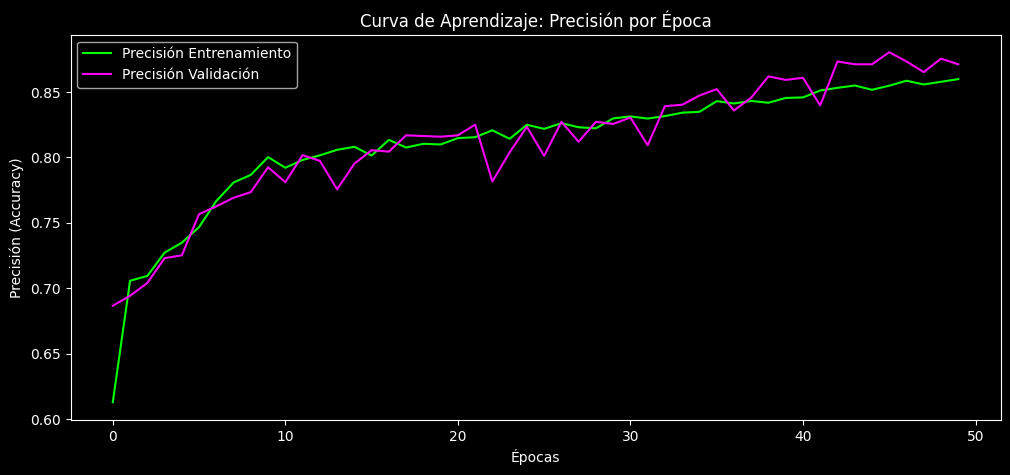

58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8756 - loss: 0.2887

RESULTADO FINAL:
La Inteligencia Artificial clasifica los exoplanetas con una precisión del: 87.13%


In [9]:
# Extraemos el historial
history_df = pd.DataFrame(history.history)

# Gráfico de Precisión (Accuracy)
plt.figure(figsize=(12, 5))
plt.plot(history_df['accuracy'], label='Precisión Entrenamiento', color='#00ff00')
plt.plot(history_df['val_accuracy'], label='Precisión Validación', color='#ff00ff')
plt.title('Curva de Aprendizaje: Precisión por Época')
plt.xlabel('Épocas')
plt.ylabel('Precisión (Accuracy)')
plt.legend()
plt.show()

# Evaluación final con datos nunca vistos
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"\nRESULTADO FINAL:")
print(f"La Inteligencia Artificial clasifica los exoplanetas con una precisión del: {accuracy*100:.2f}%")